# VisionGuard AI — MVTec AD Dataset Exploration & EDA

A clean Google Colab / Jupyter notebook for exploring, auditing, profiling, and visualizing the prepared MVTec AD dataset used by VisionGuard AI.

**Categories:** `screw` · `bottle` · `capsule` · `metal_nut` · `hazelnut`

**Input dataset:** automatically detected from the current project/Colab environment.

This notebook analyzes the dataset prepared by `01_dataset_download_and_preparation.ipynb`. It does **not** download, copy, rename, delete, or modify the prepared dataset.


## Workflow

1. Install EDA dependencies
2. Import libraries
3. Configure the prepared dataset
4. Create visualization export utilities
5. Validate the dataset root and categories
6. Build dataset statistics
7. Analyze train/test distribution
8. Discover defect types dynamically
9. Analyze defect distribution
10. Audit image integrity
11. Analyze image dimensions and aspect ratios
12. Analyze file formats and color modes
13. Analyze training-set pixel statistics
14. Generate representative visual EDA
15. Run final verification
16. Expose reusable variables for the next VisionGuard AI notebooks

## Installation

In [1]:
%pip install -q -U pandas numpy matplotlib "plotly[kaleido]" pillow

Note: you may need to restart the kernel to use updated packages.


## Imports

In [2]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from PIL import Image, UnidentifiedImageError
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 80)

print("Libraries imported successfully.")


Libraries imported successfully.


## Configuration

In [3]:
CATEGORIES = [
    "screw",
    "bottle",
    "capsule",
    "metal_nut",
    "hazelnut",
]

IMAGE_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
}

DATASET_ROOT = Path("visionguard_data")
IMAGE_FOLDER = Path("images")
TABLE_FOLDER = Path("table")

PIXEL_STATS_SAMPLE_PER_CATEGORY = 100
VISUAL_SAMPLE_PER_CATEGORY = 1

if not DATASET_ROOT.is_dir():
    raise FileNotFoundError(
        "Prepared dataset folder 'visionguard_data' was not found. "
        "Run the dataset preparation notebook first."
    )

IMAGE_FOLDER.mkdir(parents=True, exist_ok=True)
TABLE_FOLDER.mkdir(parents=True, exist_ok=True)

print("Requested categories:", ", ".join(CATEGORIES))
print("EDA configuration ready.")


Requested categories: screw, bottle, capsule, metal_nut, hazelnut
EDA configuration ready.


## Visualization Export Utilities

In [4]:
def safe_title_filename(title):
    """Convert a figure title into a clean filename while preserving the title."""
    filename = re.sub(r"<[^>]+>", "", str(title))
    filename = re.sub(r"[^A-Za-z0-9\s_-]", "", filename)
    filename = re.sub(r"\s+", " ", filename.strip())

    return filename if filename else "Untitled Visualization"


def safe_error_message(error):
    message = str(error)
    message = re.sub(r"[A-Za-z]:\\[^\n\r\t'\"]+", "[hidden]", message)
    message = re.sub(r"/(?:[^\n\r\t'\"]+/)*[^\n\r\t'\"]+", "[hidden]", message)
    return message


def figure_title(fig, fallback):
    title = fig.layout.title.text

    if title is None:
        title = fallback

    title = re.sub(r"<[^>]+>", "", str(title)).strip()

    return title if title else fallback


def save_plotly_figure(fig, fallback_title, width=1400, height=800):
    """Save every Plotly graph as both PNG and standalone HTML in images/."""
    title = figure_title(fig, fallback_title)
    filename = safe_title_filename(title)

    IMAGE_FOLDER.mkdir(parents=True, exist_ok=True)

    png_file = IMAGE_FOLDER / f"{filename}.png"
    html_file = IMAGE_FOLDER / f"{filename}.html"

    try:
        fig.write_html(
            str(html_file),
            include_plotlyjs=True,
            full_html=True,
        )
        print(f"Plotly HTML saved: {filename}.html")
    except Exception as error:
        print(
            f"Plotly HTML export failed for '{filename}': "
            f"{type(error).__name__}"
        )

    try:
        fig.write_image(
            str(png_file),
            width=width,
            height=height,
            scale=2,
        )
        print(f"Plotly PNG saved: {filename}.png")
    except Exception as error:
        print(
            f"Plotly PNG export failed for '{filename}': "
            f"{type(error).__name__}"
        )


def save_matplotlib_figure(fig, title, dpi=220):
    """Save Matplotlib figures as PNG using the exact displayed title."""
    filename = safe_title_filename(title)

    IMAGE_FOLDER.mkdir(parents=True, exist_ok=True)

    output_file = IMAGE_FOLDER / f"{filename}.png"

    try:
        fig.savefig(
            str(output_file),
            dpi=dpi,
            bbox_inches="tight",
        )
        print(f"Matplotlib PNG saved: {filename}.png")
    except Exception as error:
        print(
            f"Matplotlib PNG export failed for '{filename}': "
            f"{type(error).__name__}"
        )


def save_eda_table(dataframe, filename):
    """Save an EDA DataFrame as CSV without exposing filesystem locations."""
    if dataframe is None:
        return

    output_name = safe_title_filename(Path(filename).stem) + ".csv"

    try:
        dataframe.to_csv(
            TABLE_FOLDER / output_name,
            index=False,
        )
        print(f"Table saved: {output_name}")
    except Exception as error:
        print(
            f"Table export failed for '{output_name}': "
            f"{type(error).__name__}"
        )


print("Visualization and table export utilities ready.")
print("Plotly graphs -> PNG + HTML")
print("Matplotlib figures -> PNG")
print("EDA tables -> CSV")


Visualization and table export utilities ready.
Plotly graphs -> PNG + HTML
Matplotlib figures -> PNG
EDA tables -> CSV


## File Utilities

In [5]:
def is_image_file(path):
    path = Path(path)
    return path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS


def iter_image_files(directory):
    directory = Path(directory)

    if not directory.exists():
        return []

    return sorted(
        [
            item
            for item in directory.rglob("*")
            if is_image_file(item)
        ],
        key=lambda item: str(item).casefold(),
    )


def count_images(directory):
    return len(iter_image_files(directory))


def directory_size_bytes(directory):
    directory = Path(directory)

    if not directory.exists():
        return 0

    return sum(
        item.stat().st_size
        for item in directory.rglob("*")
        if item.is_file()
    )


def bytes_to_gb(value):
    return value / (1024 ** 3)


def read_rgb(path):
    with Image.open(path) as image:
        return image.convert("RGB").copy()


def read_gray(path):
    with Image.open(path) as image:
        return image.convert("L").copy()


def find_first_image(directory):
    files = iter_image_files(directory)
    return files[0] if files else None


print("File utilities ready.")

File utilities ready.


## Validate Prepared Dataset Root

In [6]:
if not DATASET_ROOT.is_dir():
    raise FileNotFoundError(
        "Prepared dataset folder 'visionguard_data' was not found. "
        "Run the dataset preparation notebook first."
    )

print("Prepared dataset folder found.")


Prepared dataset folder found.


## Check Requested Categories

In [7]:
category_rows = []

for category in CATEGORIES:
    category_root = DATASET_ROOT / category
    category_rows.append(
        {
            "Category": category,
            "Exists": category_root.is_dir(),
            "Train": (category_root / "train").is_dir(),
            "Test": (category_root / "test").is_dir(),
            "Ground Truth": (category_root / "ground_truth").is_dir(),
        }
    )

category_status_df = pd.DataFrame(category_rows)
display(category_status_df)

missing_categories = category_status_df.loc[
    ~category_status_df["Exists"],
    "Category",
].tolist()

if missing_categories:
    print(
        "WARNING: Missing requested categories -> "
        + ", ".join(missing_categories)
    )
else:
    print("All requested categories are present.")

,Category,Exists,Train,Test,Ground Truth
0,screw,True,True,True,True
1,bottle,True,True,True,True
2,capsule,True,True,True,True
3,metal_nut,True,True,True,True
4,hazelnut,True,True,True,True


All requested categories are present.


## Plotly — Category Availability

In [8]:
availability_plot_df = category_status_df.melt(
    id_vars="Category",
    value_vars=["Train", "Test", "Ground Truth"],
    var_name="Component",
    value_name="Available",
)

availability_plot_df["Available"] = (
    availability_plot_df["Available"].astype(int)
)

fig = px.bar(
    availability_plot_df,
    x="Category",
    y="Available",
    color="Component",
    barmode="group",
    text_auto=True,
    title="MVTec AD Category Component Availability",
    labels={
        "Available": "Available",
        "Category": "Category",
    },
)

fig.update_layout(
    yaxis=dict(
        tickmode="array",
        tickvals=[0, 1],
        ticktext=["Missing", "Present"],
    )
)

save_plotly_figure(
    fig,
    "MVTec AD Category Component Availability",
)
fig.show()

Plotly HTML saved: MVTec AD Category Component Availability.html
Plotly PNG export failed for 'MVTec AD Category Component Availability': RuntimeError


## Dataset Inventory Functions

In [9]:
def split_root(category, split):
    return DATASET_ROOT / category / split


def defect_types(category):
    test_root = split_root(category, "test")

    if not test_root.is_dir():
        return []

    return sorted(
        [
            item.name
            for item in test_root.iterdir()
            if item.is_dir()
        ],
        key=str.casefold,
    )


def split_image_count(category, split):
    return count_images(split_root(category, split))


def category_sample_image_count(category):
    return (
        split_image_count(category, "train")
        + split_image_count(category, "test")
    )


def category_mask_count(category):
    return count_images(DATASET_ROOT / category / "ground_truth")


print("Dataset inventory functions ready.")

Dataset inventory functions ready.


## Dataset Statistics

In [10]:
summary_rows = []

for category in CATEGORIES:
    category_root = DATASET_ROOT / category

    train_images = split_image_count(category, "train")
    test_images = split_image_count(category, "test")
    ground_truth_masks = category_mask_count(category)
    sample_images = train_images + test_images

    summary_rows.append(
        {
            "Category": category,
            "Train Images": train_images,
            "Test Images": test_images,
            "Sample Images": sample_images,
            "Ground Truth Masks": ground_truth_masks,
            "Size (GB)": bytes_to_gb(
                directory_size_bytes(category_root)
            ),
        }
    )

summary_df = pd.DataFrame(summary_rows)

summary_display_df = summary_df.copy()
summary_display_df["Size (GB)"] = summary_display_df["Size (GB)"].round(4)

display(summary_display_df)

,Category,Train Images,Test Images,Sample Images,Ground Truth Masks,Size (GB)
0,screw,320,160,480,119,0.1825
1,bottle,209,83,292,63,0.1458
2,capsule,219,132,351,109,0.3770
3,metal_nut,220,115,335,93,0.1545
4,hazelnut,391,110,501,70,0.5752


## Add Overall Total

In [11]:
total_record = pd.DataFrame(
    [
        {
            "Category": "TOTAL",
            "Train Images": summary_df["Train Images"].sum(),
            "Test Images": summary_df["Test Images"].sum(),
            "Sample Images": summary_df["Sample Images"].sum(),
            "Ground Truth Masks": summary_df["Ground Truth Masks"].sum(),
            "Size (GB)": summary_df["Size (GB)"].sum(),
        }
    ]
)

summary_with_total_df = pd.concat(
    [summary_df, total_record],
    ignore_index=True,
)

summary_with_total_df["Size (GB)"] = (
    summary_with_total_df["Size (GB)"].round(4)
)

display(summary_with_total_df)

,Category,Train Images,Test Images,Sample Images,Ground Truth Masks,Size (GB)
0,screw,320,160,480,119,0.1825
1,bottle,209,83,292,63,0.1458
2,capsule,219,132,351,109,0.3770
3,metal_nut,220,115,335,93,0.1545
4,hazelnut,391,110,501,70,0.5752
5,TOTAL,1359,600,1959,454,1.4349


## Key Dataset Totals

In [12]:
TOTAL_TRAIN_IMAGES = int(summary_df["Train Images"].sum())
TOTAL_TEST_IMAGES = int(summary_df["Test Images"].sum())
TOTAL_SAMPLE_IMAGES = int(summary_df["Sample Images"].sum())
TOTAL_MASK_IMAGES = int(summary_df["Ground Truth Masks"].sum())
TOTAL_DATASET_GB = float(summary_df["Size (GB)"].sum())

print(f"Total training images: {TOTAL_TRAIN_IMAGES:,}")
print(f"Total test images: {TOTAL_TEST_IMAGES:,}")
print(f"Total sample images: {TOTAL_SAMPLE_IMAGES:,}")
print(f"Total ground-truth masks: {TOTAL_MASK_IMAGES:,}")
print(f"Total prepared dataset size: {TOTAL_DATASET_GB:.4f} GB")

Total training images: 1,359
Total test images: 600
Total sample images: 1,959
Total ground-truth masks: 454
Total prepared dataset size: 1.4349 GB


## Plotly — Category Distribution

In [13]:
category_distribution_df = summary_df.melt(
    id_vars="Category",
    value_vars=["Train Images", "Test Images"],
    var_name="Split",
    value_name="Images",
)

fig = px.bar(
    category_distribution_df,
    x="Category",
    y="Images",
    color="Split",
    barmode="group",
    text_auto=True,
    title="Sample Image Distribution by Category",
)

fig.update_layout(
    xaxis_title="Category",
    yaxis_title="Images",
)

save_plotly_figure(
    fig,
    "Sample Image Distribution by Category",
)
fig.show()

Plotly HTML saved: Sample Image Distribution by Category.html
Plotly PNG export failed for 'Sample Image Distribution by Category': RuntimeError


## Plotly — Train/Test Composition

In [14]:
train_test_composition_df = summary_df.melt(
    id_vars="Category",
    value_vars=["Train Images", "Test Images"],
    var_name="Split",
    value_name="Images",
)

fig = px.bar(
    train_test_composition_df,
    x="Category",
    y="Images",
    color="Split",
    barmode="stack",
    text_auto=True,
    title="Train vs Test Composition",
)

fig.update_layout(
    xaxis_title="Category",
    yaxis_title="Images",
)

save_plotly_figure(
    fig,
    "Train vs Test Composition",
)
fig.show()

Plotly HTML saved: Train vs Test Composition.html
Plotly PNG export failed for 'Train vs Test Composition': RuntimeError


## Plotly — Ground-Truth Mask Distribution

In [15]:
mask_distribution_df = summary_df[
    ["Category", "Ground Truth Masks"]
].copy()

fig = px.bar(
    mask_distribution_df,
    x="Category",
    y="Ground Truth Masks",
    text_auto=True,
    title="Ground-Truth Mask Distribution",
)

fig.update_layout(
    xaxis_title="Category",
    yaxis_title="Mask Images",
)

save_plotly_figure(
    fig,
    "Ground-Truth Mask Distribution",
)
fig.show()

Plotly HTML saved: Ground-Truth Mask Distribution.html
Plotly PNG export failed for 'Ground-Truth Mask Distribution': RuntimeError


## Defect Discovery

In [16]:
defect_rows = []

for category in CATEGORIES:
    for defect_type in defect_types(category):
        defect_rows.append(
            {
                "Category": category,
                "Defect Type": defect_type,
                "Test Images": count_images(
                    split_root(category, "test") / defect_type
                ),
            }
        )

defect_df = pd.DataFrame(
    defect_rows,
    columns=["Category", "Defect Type", "Test Images"],
)

if defect_df.empty:
    print("No test defect directories were discovered.")
else:
    display(defect_df)
    print(
        f"Unique defect directories discovered: "
        f"{defect_df['Defect Type'].nunique()}"
    )

,Category,Defect Type,Test Images
0,screw,good,41
1,screw,manipulated_front,24
2,screw,scratch_head,24
3,screw,scratch_neck,25
4,screw,thread_side,23
5,screw,thread_top,23
6,bottle,broken_large,20
7,bottle,broken_small,22
8,bottle,contamination,21
9,bottle,good,20


Unique defect directories discovered: 20


## Defect Type Inventory by Category

In [17]:
defect_inventory_df = (
    defect_df.groupby("Category")["Defect Type"]
    .agg(list)
    .reindex(CATEGORIES)
    .reset_index()
)

defect_inventory_df["Defect Types"] = defect_inventory_df["Defect Type"].apply(
    lambda values: ", ".join(values) if isinstance(values, list) else ""
)

defect_inventory_df = defect_inventory_df[
    ["Category", "Defect Types"]
]

display(defect_inventory_df)

,Category,Defect Types
0,screw,"good, manipulated_front, scratch_head, scratch_neck, thread_side, thread_top"
1,bottle,"broken_large, broken_small, contamination, good"
2,capsule,"crack, faulty_imprint, good, poke, scratch, squeeze"
3,metal_nut,"bent, color, flip, good, scratch"
4,hazelnut,"crack, cut, good, hole, print"


## Plotly — Defect Distribution

In [18]:
if defect_df.empty:
    print("No defect data available for plotting.")
else:
    defect_plot_df = defect_df[
        defect_df["Defect Type"].str.casefold() != "good"
    ].copy()

    if defect_plot_df.empty:
        print("No defective test directories were discovered.")
    else:
        fig = px.bar(
            defect_plot_df,
            x="Defect Type",
            y="Test Images",
            color="Category",
            barmode="group",
            text_auto=True,
            title="Defect Distribution Across Selected Categories",
        )

        fig.update_layout(
            xaxis_title="Defect Type",
            yaxis_title="Test Images",
        )

        save_plotly_figure(
            fig,
            "Defect Distribution Across Selected Categories",
        )
        fig.show()

Plotly HTML saved: Defect Distribution Across Selected Categories.html
Plotly PNG export failed for 'Defect Distribution Across Selected Categories': RuntimeError


## Good vs Defective Test Images

In [19]:
if defect_df.empty:
    status_distribution_df = pd.DataFrame(
        columns=["Category", "Status", "Test Images"]
    )
else:
    status_distribution_df = defect_df.copy()
    status_distribution_df["Status"] = np.where(
        status_distribution_df["Defect Type"].str.casefold().eq("good"),
        "Good",
        "Defective",
    )

    status_distribution_df = (
        status_distribution_df
        .groupby(["Category", "Status"], as_index=False)["Test Images"]
        .sum()
    )

display(status_distribution_df)

,Category,Status,Test Images
0,bottle,Defective,63
1,bottle,Good,20
2,capsule,Defective,109
3,capsule,Good,23
4,hazelnut,Defective,70
5,hazelnut,Good,40
6,metal_nut,Defective,93
7,metal_nut,Good,22
8,screw,Defective,119
9,screw,Good,41


## Plotly — Good vs Defective

In [20]:
if status_distribution_df.empty:
    print("No test-status data available for plotting.")
else:
    fig = px.bar(
        status_distribution_df,
        x="Category",
        y="Test Images",
        color="Status",
        barmode="group",
        text_auto=True,
        title="Good vs Defective Test Images",
    )

    fig.update_layout(
        xaxis_title="Category",
        yaxis_title="Test Images",
    )

    save_plotly_figure(
        fig,
        "Good vs Defective Test Images",
    )
    fig.show()

Plotly HTML saved: Good vs Defective Test Images.html
Plotly PNG export failed for 'Good vs Defective Test Images': RuntimeError


## Defective Image Share

In [21]:
if defect_df.empty:
    defective_share_df = pd.DataFrame(
        columns=["Category", "Defective Images", "Total Test Images", "Defective Share (%)"]
    )
else:
    total_test_by_category = (
        defect_df.groupby("Category")["Test Images"]
        .sum()
        .rename("Total Test Images")
    )

    defective_by_category = (
        defect_df.loc[
            defect_df["Defect Type"].str.casefold() != "good"
        ]
        .groupby("Category")["Test Images"]
        .sum()
        .rename("Defective Images")
    )

    defective_share_df = (
        pd.concat(
            [defective_by_category, total_test_by_category],
            axis=1,
        )
        .fillna(0)
        .reindex(CATEGORIES)
        .reset_index()
        .rename(columns={"index": "Category"})
    )

    defective_share_df["Defective Share (%)"] = np.where(
        defective_share_df["Total Test Images"] > 0,
        defective_share_df["Defective Images"]
        / defective_share_df["Total Test Images"]
        * 100,
        0,
    )

    defective_share_df["Defective Share (%)"] = (
        defective_share_df["Defective Share (%)"].round(2)
    )

display(defective_share_df)

,Category,Defective Images,Total Test Images,Defective Share (%)
0,screw,119,160,74.38
1,bottle,63,83,75.90
2,capsule,109,132,82.58
3,metal_nut,93,115,80.87
4,hazelnut,70,110,63.64


## Plotly — Defective Category Share

In [22]:
if defective_share_df.empty:
    print("No defective-share data available for plotting.")
else:
    fig = px.bar(
        defective_share_df,
        x="Category",
        y="Defective Share (%)",
        text="Defective Share (%)",
        title="Defective Test Image Share by Category",
    )

    fig.update_traces(
        texttemplate="%{text:.2f}%",
        textposition="outside",
    )

    fig.update_layout(
        xaxis_title="Category",
        yaxis_title="Defective Share (%)",
    )

    save_plotly_figure(
        fig,
        "Defective Test Image Share by Category",
    )
    fig.show()

Plotly HTML saved: Defective Test Image Share by Category.html
Plotly PNG export failed for 'Defective Test Image Share by Category': RuntimeError


## Full Image Integrity Audit

In [23]:
def audit_image(path):
    path = Path(path)

    try:
        with Image.open(path) as image:
            image.verify()

        with Image.open(path) as image:
            image.load()
            width, height = image.size
            mode = image.mode
            format_name = image.format

        return {
            "Valid": True,
            "Width": width,
            "Height": height,
            "Mode": mode,
            "Format": format_name,
            "Error": "",
        }

    except (
        UnidentifiedImageError,
        OSError,
        ValueError,
    ) as error:
        return {
            "Valid": False,
            "Width": np.nan,
            "Height": np.nan,
            "Mode": None,
            "Format": None,
            "Error": safe_error_message(error),
        }


def image_split_from_path(path):
    parts = Path(path).parts

    if "train" in parts:
        return "train"

    if "test" in parts:
        return "test"

    if "ground_truth" in parts:
        return "ground_truth"

    return "other"


audit_rows = []

for category in CATEGORIES:
    category_root = DATASET_ROOT / category

    for image_path in iter_image_files(category_root):
        result = audit_image(image_path)

        audit_rows.append(
            {
                "Category": category,
                "Split": image_split_from_path(image_path),
                "File": image_path.name,
                "Extension": image_path.suffix.lower(),
                **result,
            }
        )

audit_df = pd.DataFrame(audit_rows)

print(f"Images audited: {len(audit_df):,}")

if not audit_df.empty:
    print(
        f"Valid images: "
        f"{int(audit_df['Valid'].sum()):,}"
    )
    print(
        f"Invalid images: "
        f"{int((~audit_df['Valid']).sum()):,}"
    )
else:
    print("No image files were found under the selected categories.")

Images audited: 2,413
Valid images: 2,413
Invalid images: 0


## Corrupt / Unreadable Image Report

In [24]:
invalid_df = audit_df.loc[
    ~audit_df["Valid"]
].copy()

if invalid_df.empty:
    print("No invalid or unreadable images were detected.")
else:
    print(
        f"WARNING: {len(invalid_df):,} invalid or unreadable "
        f"image file(s) detected."
    )

    display(
        invalid_df[
            [
                "Category",
                "Split",
                "Extension",
                "Error",
            ]
        ]
    )


No invalid or unreadable images were detected.


## Integrity Summary

In [25]:
integrity_summary_df = (
    audit_df.groupby(["Category", "Split"])["Valid"]
    .agg(
        Images="size",
        Valid="sum",
    )
    .reset_index()
)

if not integrity_summary_df.empty:
    integrity_summary_df["Invalid"] = (
        integrity_summary_df["Images"]
        - integrity_summary_df["Valid"]
    )

    integrity_summary_df["Validity (%)"] = np.where(
        integrity_summary_df["Images"] > 0,
        integrity_summary_df["Valid"]
        / integrity_summary_df["Images"]
        * 100,
        0,
    ).round(2)

display(integrity_summary_df)

,Category,Split,Images,Valid,Invalid,Validity (%)
0,bottle,ground_truth,63,63,0,100.0
1,bottle,test,83,83,0,100.0
2,bottle,train,209,209,0,100.0
3,capsule,ground_truth,109,109,0,100.0
4,capsule,test,132,132,0,100.0
5,capsule,train,219,219,0,100.0
6,hazelnut,ground_truth,70,70,0,100.0
7,hazelnut,test,110,110,0,100.0
8,hazelnut,train,391,391,0,100.0
9,metal_nut,ground_truth,93,93,0,100.0


## Image Dimensions

In [26]:
valid_audit_df = audit_df[
    audit_df["Valid"]
].copy()

dimension_df = (
    valid_audit_df.groupby(
        ["Category", "Split", "Width", "Height"]
    )
    .size()
    .reset_index(name="Images")
    .sort_values(
        ["Category", "Split", "Width", "Height"]
    )
)

display(dimension_df.head(50))

,Category,Split,Width,Height,Images
0,bottle,ground_truth,900,900,63
1,bottle,test,900,900,83
2,bottle,train,900,900,209
3,capsule,ground_truth,1000,1000,109
4,capsule,test,1000,1000,132
5,capsule,train,1000,1000,219
6,hazelnut,ground_truth,1024,1024,70
7,hazelnut,test,1024,1024,110
8,hazelnut,train,1024,1024,391
9,metal_nut,ground_truth,700,700,93


## Common Dimensions by Category

In [27]:
if valid_audit_df.empty:
    common_dimension_df = pd.DataFrame(
        columns=[
            "Category",
            "Split",
            "Width",
            "Height",
            "Images",
            "Share (%)",
        ]
    )
else:
    common_dimension_df = dimension_df.copy()

    totals = common_dimension_df.groupby(
        ["Category", "Split"]
    )["Images"].transform("sum")

    common_dimension_df["Share (%)"] = np.where(
        totals > 0,
        common_dimension_df["Images"] / totals * 100,
        0,
    ).round(2)

    common_dimension_df = (
        common_dimension_df
        .sort_values(
            ["Category", "Split", "Images"],
            ascending=[True, True, False],
        )
        .groupby(["Category", "Split"], as_index=False)
        .head(5)
    )

display(common_dimension_df)

,Category,Split,Width,Height,Images,Share (%)
0,bottle,ground_truth,900,900,63,100.0
1,bottle,test,900,900,83,100.0
2,bottle,train,900,900,209,100.0
3,capsule,ground_truth,1000,1000,109,100.0
4,capsule,test,1000,1000,132,100.0
5,capsule,train,1000,1000,219,100.0
6,hazelnut,ground_truth,1024,1024,70,100.0
7,hazelnut,test,1024,1024,110,100.0
8,hazelnut,train,1024,1024,391,100.0
9,metal_nut,ground_truth,700,700,93,100.0


## Plotly — Width Distribution

In [28]:
if valid_audit_df.empty:
    print("No valid images available for dimension analysis.")
else:
    fig = px.histogram(
        valid_audit_df,
        x="Width",
        color="Category",
        marginal="box",
        nbins=35,
        title="Image Width Distribution",
    )

    fig.update_layout(
        xaxis_title="Width (pixels)",
        yaxis_title="Image Count",
    )

    save_plotly_figure(
        fig,
        "Image Width Distribution",
    )
    fig.show()

Plotly HTML saved: Image Width Distribution.html
Plotly PNG export failed for 'Image Width Distribution': RuntimeError


## Plotly — Height Distribution

In [29]:
if valid_audit_df.empty:
    print("No valid images available for dimension analysis.")
else:
    fig = px.histogram(
        valid_audit_df,
        x="Height",
        color="Category",
        marginal="box",
        nbins=35,
        title="Image Height Distribution",
    )

    fig.update_layout(
        xaxis_title="Height (pixels)",
        yaxis_title="Image Count",
    )

    save_plotly_figure(
        fig,
        "Image Height Distribution",
    )
    fig.show()

Plotly HTML saved: Image Height Distribution.html
Plotly PNG export failed for 'Image Height Distribution': RuntimeError


## Image Aspect Ratio

In [30]:
if valid_audit_df.empty:
    aspect_ratio_df = pd.DataFrame(
        columns=["Category", "Split", "Aspect Ratio"]
    )
    aspect_ratio_summary_df = pd.DataFrame(
        columns=["Category", "Split", "min", "median", "max"]
    )
else:
    aspect_ratio_df = valid_audit_df[
        ["Category", "Split", "Width", "Height"]
    ].copy()

    aspect_ratio_df["Aspect Ratio"] = (
        aspect_ratio_df["Width"]
        / aspect_ratio_df["Height"]
    )

    aspect_ratio_summary_df = (
        aspect_ratio_df[
            ["Category", "Split", "Aspect Ratio"]
        ]
        .groupby(["Category", "Split"])["Aspect Ratio"]
        .agg(["min", "median", "max"])
        .reset_index()
        .round(4)
    )

display(aspect_ratio_summary_df)


,Category,Split,min,median,max
0,bottle,ground_truth,1.0,1.0,1.0
1,bottle,test,1.0,1.0,1.0
2,bottle,train,1.0,1.0,1.0
3,capsule,ground_truth,1.0,1.0,1.0
4,capsule,test,1.0,1.0,1.0
5,capsule,train,1.0,1.0,1.0
6,hazelnut,ground_truth,1.0,1.0,1.0
7,hazelnut,test,1.0,1.0,1.0
8,hazelnut,train,1.0,1.0,1.0
9,metal_nut,ground_truth,1.0,1.0,1.0


## Plotly — Aspect Ratio

In [31]:
if valid_audit_df.empty:
    print("No valid images available for aspect-ratio analysis.")
else:
    aspect_plot_df = valid_audit_df.copy()
    aspect_plot_df["Aspect Ratio"] = (
        aspect_plot_df["Width"]
        / aspect_plot_df["Height"]
    )

    fig = px.box(
        aspect_plot_df,
        x="Category",
        y="Aspect Ratio",
        color="Category",
        points=False,
        title="Image Aspect Ratio Distribution",
    )

    fig.update_layout(
        xaxis_title="Category",
        yaxis_title="Width / Height",
        showlegend=False,
    )

    save_plotly_figure(
        fig,
        "Image Aspect Ratio Distribution",
    )
    fig.show()

Plotly HTML saved: Image Aspect Ratio Distribution.html
Plotly PNG export failed for 'Image Aspect Ratio Distribution': RuntimeError


## File Extension Distribution

In [32]:
extension_df = (
    audit_df.groupby(
        ["Category", "Split", "Extension"]
    )
    .size()
    .reset_index(name="Images")
    .sort_values(
        ["Category", "Split", "Images"],
        ascending=[True, True, False],
    )
)

display(extension_df)

,Category,Split,Extension,Images
0,bottle,ground_truth,.png,63
1,bottle,test,.png,83
2,bottle,train,.png,209
3,capsule,ground_truth,.png,109
4,capsule,test,.png,132
5,capsule,train,.png,219
6,hazelnut,ground_truth,.png,70
7,hazelnut,test,.png,110
8,hazelnut,train,.png,391
9,metal_nut,ground_truth,.png,93


## Plotly — File Formats

In [33]:
if extension_df.empty:
    print("No image extension data available.")
else:
    fig = px.bar(
        extension_df,
        x="Category",
        y="Images",
        color="Extension",
        barmode="group",
        text_auto=True,
        title="Image File Format Distribution",
    )

    fig.update_layout(
        xaxis_title="Category",
        yaxis_title="Images",
    )

    save_plotly_figure(
        fig,
        "Image File Format Distribution",
    )
    fig.show()

Plotly HTML saved: Image File Format Distribution.html
Plotly PNG export failed for 'Image File Format Distribution': RuntimeError


## Color Mode Distribution

In [34]:
mode_df = (
    valid_audit_df.groupby(
        ["Category", "Split", "Mode"]
    )
    .size()
    .reset_index(name="Images")
    .sort_values(
        ["Category", "Split", "Images"],
        ascending=[True, True, False],
    )
)

display(mode_df)

,Category,Split,Mode,Images
0,bottle,ground_truth,L,63
1,bottle,test,RGB,83
2,bottle,train,RGB,209
3,capsule,ground_truth,L,109
4,capsule,test,RGB,132
5,capsule,train,RGB,219
6,hazelnut,ground_truth,L,70
7,hazelnut,test,RGB,110
8,hazelnut,train,RGB,391
9,metal_nut,ground_truth,L,93


## Plotly — Color Modes

In [35]:
if mode_df.empty:
    print("No color-mode data available.")
else:
    fig = px.bar(
        mode_df,
        x="Category",
        y="Images",
        color="Mode",
        barmode="group",
        text_auto=True,
        title="Image Color Mode Distribution",
    )

    fig.update_layout(
        xaxis_title="Category",
        yaxis_title="Images",
    )

    save_plotly_figure(
        fig,
        "Image Color Mode Distribution",
    )
    fig.show()

Plotly HTML saved: Image Color Mode Distribution.html
Plotly PNG export failed for 'Image Color Mode Distribution': RuntimeError


## Pixel Statistics

In [36]:
def pixel_statistics(path):
    try:
        image = np.asarray(
            read_rgb(path),
            dtype=np.float32,
        )

        return {
            "Mean Pixel": float(image.mean()),
            "Std Pixel": float(image.std()),
            "Min Pixel": float(image.min()),
            "Max Pixel": float(image.max()),
        }
    except Exception:
        return None


pixel_rows = []

for category in CATEGORIES:
    training_images = iter_image_files(
        DATASET_ROOT / category / "train"
    )

    selected_images = training_images[
        :min(
            PIXEL_STATS_SAMPLE_PER_CATEGORY,
            len(training_images),
        )
    ]

    for image_path in selected_images:
        stats = pixel_statistics(image_path)

        if stats is None:
            continue

        pixel_rows.append(
            {
                "Category": category,
                "File": image_path.name,
                **stats,
            }
        )

pixel_stats_df = pd.DataFrame(pixel_rows)

print(
    "Training images sampled per category: "
    f"up to {PIXEL_STATS_SAMPLE_PER_CATEGORY}"
)

display(pixel_stats_df.head(20))

Training images sampled per category: up to 100


,Category,File,Mean Pixel,Std Pixel,Min Pixel,Max Pixel
0,screw,000.png,176.720413,32.828663,30.0,210.0
1,screw,001.png,194.906204,37.658745,25.0,235.0
2,screw,002.png,194.322327,38.514114,28.0,234.0
3,screw,003.png,182.873367,34.141582,29.0,251.0
4,screw,004.png,183.909470,31.127703,36.0,217.0
5,screw,005.png,192.430298,36.342625,36.0,230.0
6,screw,006.png,184.099045,34.572453,28.0,216.0
7,screw,007.png,183.123550,33.518368,36.0,215.0
8,screw,008.png,183.047928,34.299923,29.0,216.0
9,screw,009.png,181.873169,33.940430,32.0,214.0


## Pixel Statistics Summary

In [37]:
if pixel_stats_df.empty:
    pixel_summary_df = pd.DataFrame()
    print("No pixel statistics could be calculated.")
else:
    pixel_summary_df = (
        pixel_stats_df.groupby("Category")
        [
            [
                "Mean Pixel",
                "Std Pixel",
                "Min Pixel",
                "Max Pixel",
            ]
        ]
        .agg(
            [
                "mean",
                "median",
                "std",
            ]
        )
        .round(4)
    )

    display(pixel_summary_df)

Mean Pixel                   Std Pixel                  Min Pixel                Max Pixel                
                mean    median     std      mean   median     std      mean median     std      mean median      std
Category                                                                                                            
bottle      136.8186  136.7137  1.2768   92.2257  92.2575  0.4898     26.24   27.0  1.0552    255.00  255.0   0.0000
capsule     173.1493  172.3303  5.6310   65.0920  65.0822  1.7781     13.57   14.0  1.4231    252.35  255.0   6.8643
hazelnut     48.5700   48.7514  3.4228   27.3219  27.4551  3.9255     21.11   22.0  3.2408    207.63  205.5  20.8882
metal_nut    57.7227   55.3543  4.9065   41.2867  38.6191  5.2193     13.22   13.0  0.5041    254.23  255.0   5.0928
screw       183.5771  182.9358  3.6656   34.0521  34.0666  1.5784     31.51   31.0  4.0389    219.17  216.0   9.0040

## Plotly — Mean Pixel Intensity

In [38]:
if pixel_stats_df.empty:
    print("No pixel statistics available.")
else:
    fig = px.box(
        pixel_stats_df,
        x="Category",
        y="Mean Pixel",
        color="Category",
        points=False,
        title="Mean Pixel Intensity by Category",
    )

    fig.update_layout(
        xaxis_title="Category",
        yaxis_title="Mean Pixel Intensity",
        showlegend=False,
    )

    save_plotly_figure(
        fig,
        "Mean Pixel Intensity by Category",
    )
    fig.show()

Plotly HTML saved: Mean Pixel Intensity by Category.html
Plotly PNG export failed for 'Mean Pixel Intensity by Category': RuntimeError


## Plotly — Pixel Variation

In [39]:
if pixel_stats_df.empty:
    print("No pixel statistics available.")
else:
    fig = px.box(
        pixel_stats_df,
        x="Category",
        y="Std Pixel",
        color="Category",
        points=False,
        title="Pixel Intensity Variation by Category",
    )

    fig.update_layout(
        xaxis_title="Category",
        yaxis_title="Pixel Standard Deviation",
        showlegend=False,
    )

    save_plotly_figure(
        fig,
        "Pixel Intensity Variation by Category",
    )
    fig.show()

Plotly HTML saved: Pixel Intensity Variation by Category.html
Plotly PNG export failed for 'Pixel Intensity Variation by Category': RuntimeError


## Plotly — Minimum and Maximum Pixel Intensity

In [40]:
if pixel_stats_df.empty:
    print("No pixel statistics available.")
else:
    range_df = pixel_stats_df.melt(
        id_vars="Category",
        value_vars=[
            "Min Pixel",
            "Max Pixel",
        ],
        var_name="Statistic",
        value_name="Pixel Value",
    )

    fig = px.box(
        range_df,
        x="Category",
        y="Pixel Value",
        color="Statistic",
        points=False,
        title="Minimum and Maximum Pixel Intensity",
    )

    fig.update_layout(
        xaxis_title="Category",
        yaxis_title="Pixel Intensity",
    )

    save_plotly_figure(
        fig,
        "Minimum and Maximum Pixel Intensity",
    )
    fig.show()

Plotly HTML saved: Minimum and Maximum Pixel Intensity.html
Plotly PNG export failed for 'Minimum and Maximum Pixel Intensity': RuntimeError


## Representative Training Samples

In [41]:
def first_training_image(category):
    return find_first_image(
        DATASET_ROOT / category / "train"
    )


sample_visual_paths = {}
sample_rows = []

for category in CATEGORIES:
    sample_path = first_training_image(category)

    sample_visual_paths[category] = sample_path

    sample_rows.append(
        {
            "Category": category,
            "Training Sample Available": sample_path is not None,
        }
    )

sample_df = pd.DataFrame(sample_rows)

display(sample_df)


,Category,Training Sample Available
0,screw,True
1,bottle,True
2,capsule,True
3,metal_nut,True
4,hazelnut,True


## Training Sample Gallery

Matplotlib PNG saved: Representative Training Samples.png


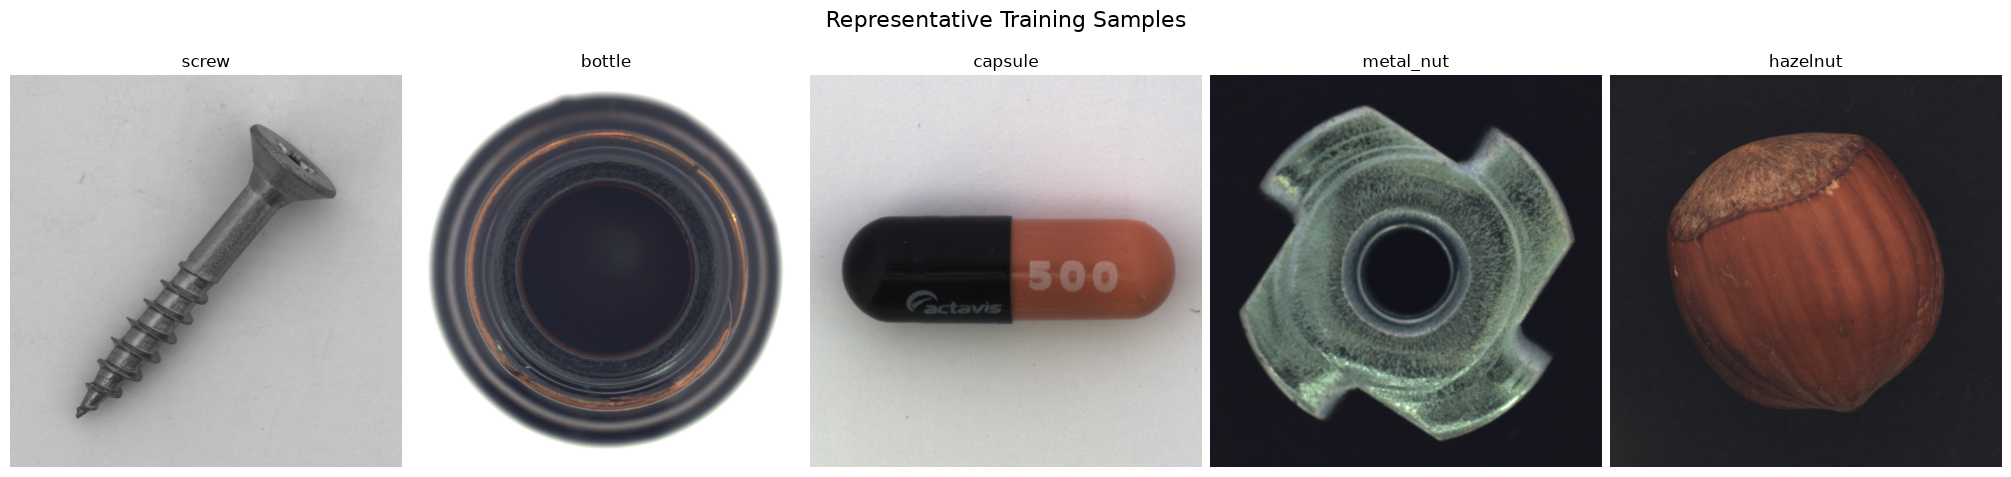

In [42]:
fig, axes = plt.subplots(
    1,
    len(CATEGORIES),
    figsize=(20, 5),
    constrained_layout=True,
)

axes = np.atleast_1d(axes)

for axis, category in zip(axes, CATEGORIES):
    sample_path = sample_visual_paths.get(category)

    if sample_path is None:
        axis.text(
            0.5,
            0.5,
            "Image unavailable",
            ha="center",
            va="center",
        )
    else:
        try:
            axis.imshow(read_rgb(sample_path))
        except Exception:
            axis.text(
                0.5,
                0.5,
                "Image unreadable",
                ha="center",
                va="center",
            )

    axis.set_title(category)
    axis.axis("off")

fig.suptitle(
    "Representative Training Samples",
    fontsize=16,
)

save_matplotlib_figure(
    fig,
    "Representative Training Samples",
)

plt.show()


## Representative Normal and Defective Samples

In [43]:
def first_good_image(category):
    good_images = iter_image_files(
        DATASET_ROOT / category / "test" / "good"
    )
    return good_images[0] if good_images else None


def first_defective_image(category):
    for defect_type in defect_types(category):
        if defect_type.casefold() == "good":
            continue

        images = iter_image_files(
            DATASET_ROOT / category / "test" / defect_type
        )

        if images:
            return defect_type, images[0]

    return None, None


representative_rows = []

for category in CATEGORIES:
    defect_type, defective_path = first_defective_image(category)

    representative_rows.append(
        {
            "Category": category,
            "Normal Image": first_good_image(category),
            "Defect Type": defect_type,
            "Defective Image": defective_path,
        }
    )

representative_df = pd.DataFrame(representative_rows)

display(
    representative_df[
        [
            "Category",
            "Defect Type",
        ]
    ]
)

,Category,Defect Type
0,screw,manipulated_front
1,bottle,broken_large
2,capsule,crack
3,metal_nut,bent
4,hazelnut,crack


## Normal and Defective Gallery

Matplotlib PNG saved: Representative Normal and Defective Test Samples.png


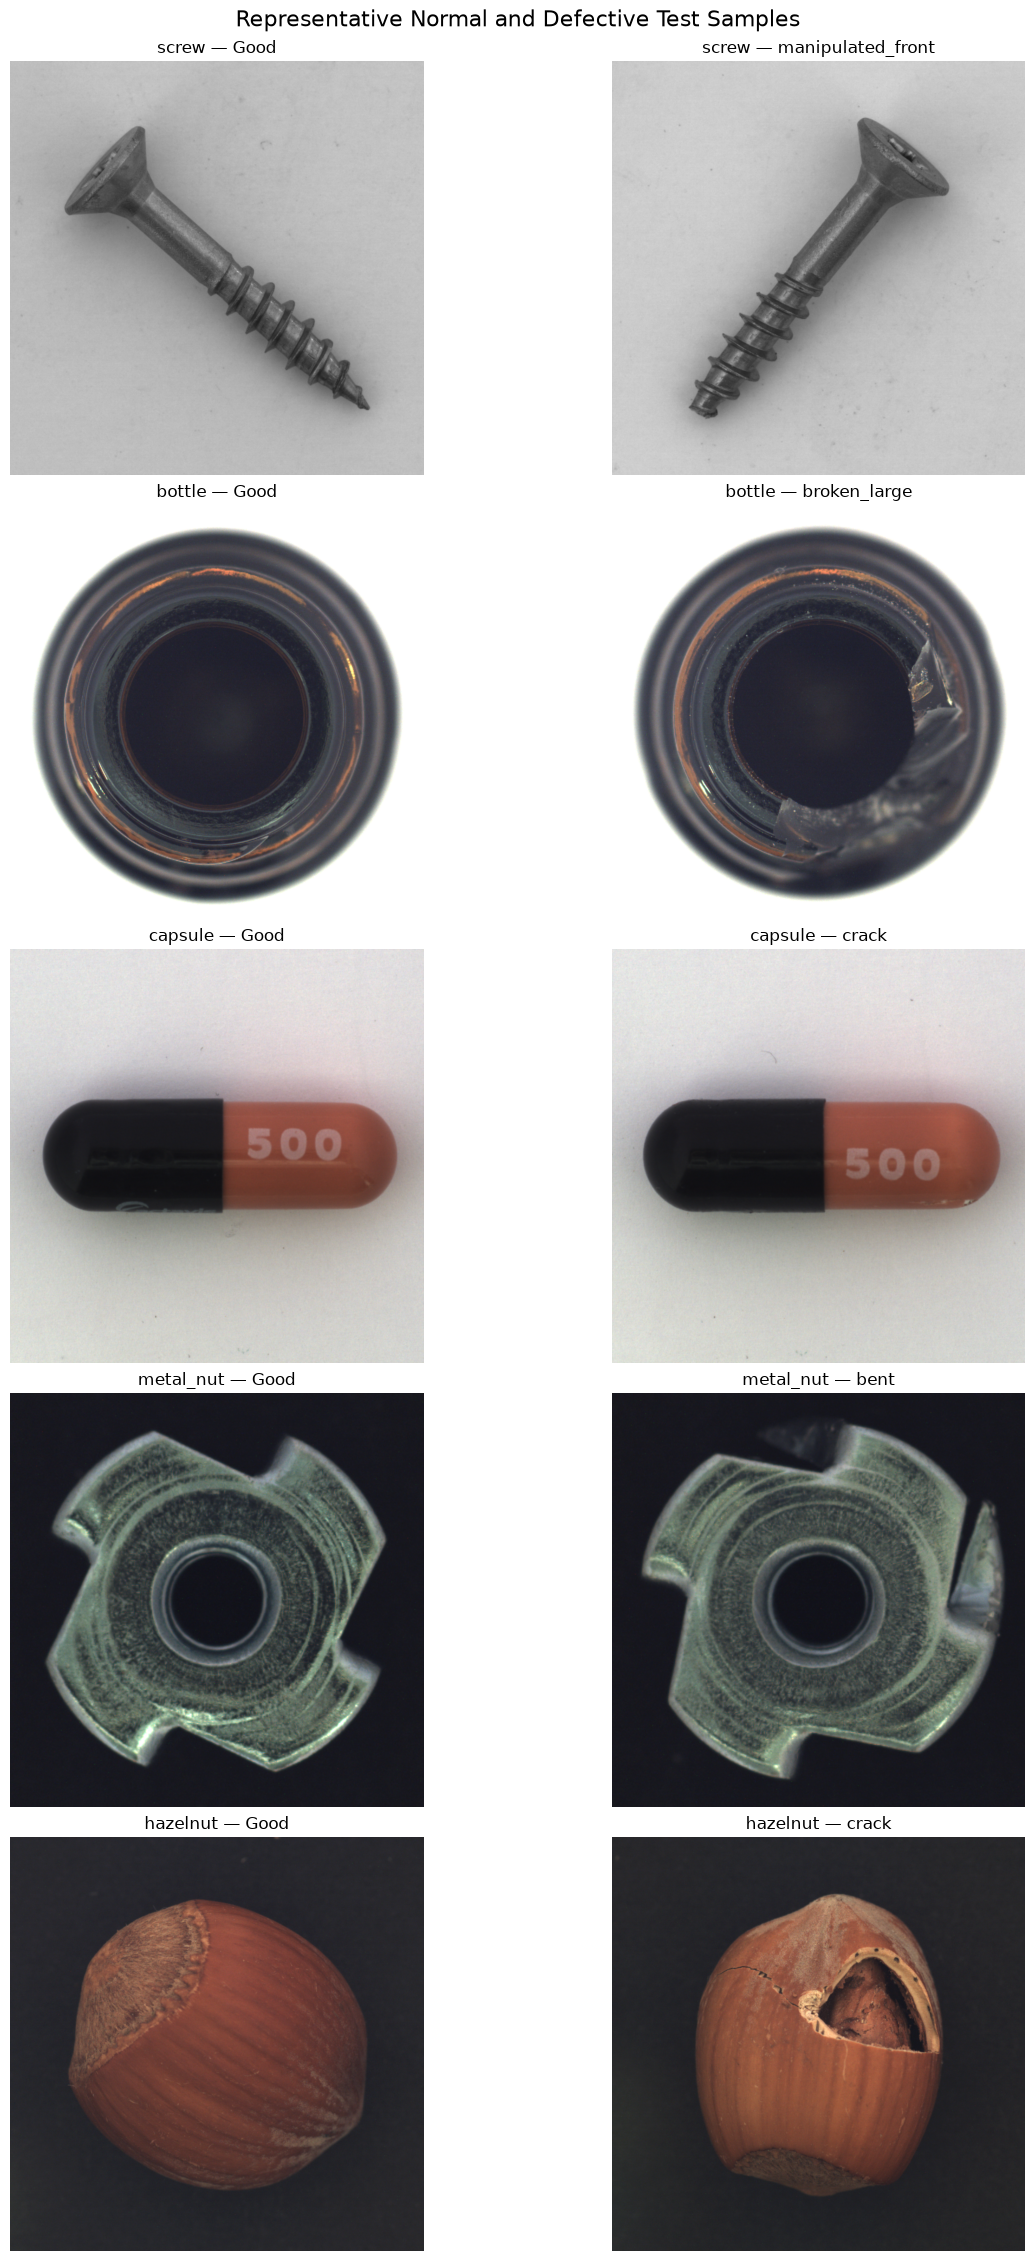

In [44]:
fig, axes = plt.subplots(
    len(CATEGORIES),
    2,
    figsize=(12, 4.5 * len(CATEGORIES)),
    constrained_layout=True,
)

axes = np.atleast_2d(axes)

for row_index, category in enumerate(CATEGORIES):
    record = representative_df.loc[
        representative_df["Category"].eq(category)
    ].iloc[0]

    normal_path = record["Normal Image"]
    defective_path = record["Defective Image"]
    defect_type = record["Defect Type"]

    left_axis = axes[row_index, 0]
    right_axis = axes[row_index, 1]

    if normal_path is not None:
        try:
            left_axis.imshow(read_rgb(normal_path))
        except Exception:
            left_axis.text(
                0.5,
                0.5,
                "Image unreadable",
                ha="center",
                va="center",
            )
    else:
        left_axis.text(
            0.5,
            0.5,
            "Normal image unavailable",
            ha="center",
            va="center",
        )

    left_axis.set_title(
        f"{category} — Good"
    )
    left_axis.axis("off")

    if defective_path is not None:
        try:
            right_axis.imshow(read_rgb(defective_path))
        except Exception:
            right_axis.text(
                0.5,
                0.5,
                "Image unreadable",
                ha="center",
                va="center",
            )
    else:
        right_axis.text(
            0.5,
            0.5,
            "Defective image unavailable",
            ha="center",
            va="center",
        )

    right_axis.set_title(
        f"{category} — {defect_type or 'Defect unavailable'}"
    )
    right_axis.axis("off")

fig.suptitle(
    "Representative Normal and Defective Test Samples",
    fontsize=16,
)

save_matplotlib_figure(
    fig,
    "Representative Normal and Defective Test Samples",
)

plt.show()

## Ground-Truth Mask Matching

In [45]:
def ground_truth_images(category):
    return iter_image_files(
        DATASET_ROOT / category / "ground_truth"
    )


def match_ground_truth(category, image_path):
    if image_path is None:
        return None

    stem = Path(image_path).stem
    defect_type = Path(image_path).parent.name

    candidates = ground_truth_images(category)

    if not candidates:
        return None

    exact_name = f"{stem}_mask"

    exact_matches = [
        mask
        for mask in candidates
        if mask.stem.casefold() == exact_name.casefold()
    ]

    if exact_matches:
        return exact_matches[0]

    same_defect_matches = [
        mask
        for mask in candidates
        if (
            defect_type
            and mask.parent.name.casefold() == defect_type.casefold()
            and mask.stem.casefold().startswith(stem.casefold())
        )
    ]

    if same_defect_matches:
        return same_defect_matches[0]

    prefix_matches = [
        mask
        for mask in candidates
        if mask.stem.casefold().startswith(stem.casefold())
    ]

    return prefix_matches[0] if prefix_matches else None


mask_visual_rows = []

for _, record in representative_df.iterrows():
    mask_path = match_ground_truth(
        record["Category"],
        record["Defective Image"],
    )

    mask_visual_rows.append(
        {
            "Category": record["Category"],
            "Defect Type": record["Defect Type"],
            "Defective Image": record["Defective Image"],
            "Ground Truth Mask": mask_path,
        }
    )

mask_visual_df = pd.DataFrame(mask_visual_rows)

mask_match_df = mask_visual_df[
    ["Category", "Defect Type"]
].copy()

mask_match_df["Ground Truth Available"] = (
    mask_visual_df["Ground Truth Mask"].notna()
)

display(mask_match_df)


,Category,Defect Type,Ground Truth Available
0,screw,manipulated_front,True
1,bottle,broken_large,True
2,capsule,crack,True
3,metal_nut,bent,True
4,hazelnut,crack,True


## Defective Image and Ground-Truth Gallery

Matplotlib PNG saved: Defective Test Samples and Ground-Truth Masks.png


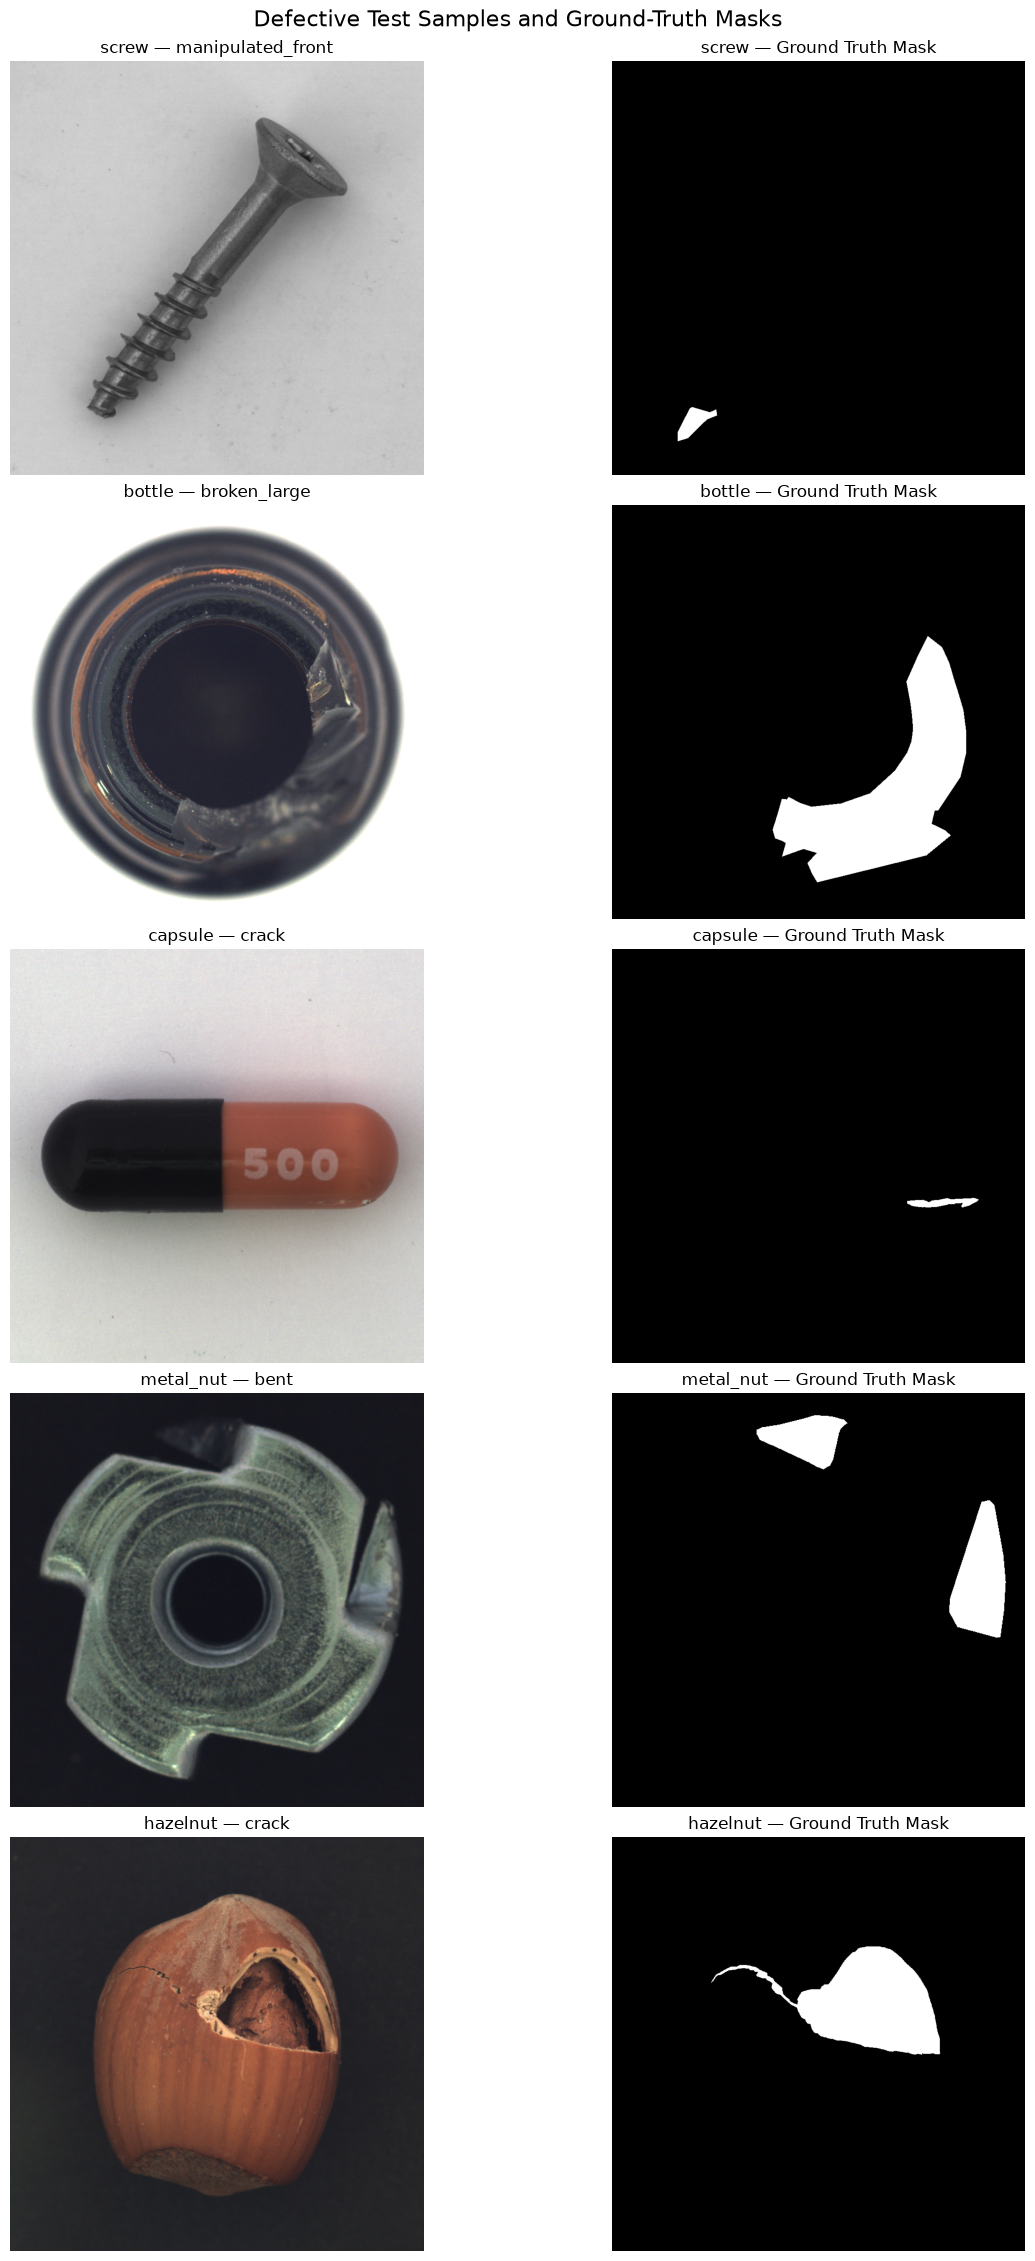

In [46]:
fig, axes = plt.subplots(
    len(CATEGORIES),
    2,
    figsize=(12, 4.5 * len(CATEGORIES)),
    constrained_layout=True,
)

axes = np.atleast_2d(axes)

for row_index, category in enumerate(CATEGORIES):
    record = mask_visual_df.loc[
        mask_visual_df["Category"].eq(category)
    ].iloc[0]

    defective_path = record["Defective Image"]
    mask_path = record["Ground Truth Mask"]
    defect_type = record["Defect Type"]

    image_axis = axes[row_index, 0]
    mask_axis = axes[row_index, 1]

    if defective_path is not None:
        try:
            image_axis.imshow(read_rgb(defective_path))
        except Exception:
            image_axis.text(
                0.5,
                0.5,
                "Image unreadable",
                ha="center",
                va="center",
            )
    else:
        image_axis.text(
            0.5,
            0.5,
            "Defective image unavailable",
            ha="center",
            va="center",
        )

    image_axis.set_title(
        f"{category} — {defect_type or 'Defect unavailable'}"
    )
    image_axis.axis("off")

    if mask_path is not None:
        try:
            mask_axis.imshow(
                read_gray(mask_path),
                cmap="gray",
            )
        except Exception:
            mask_axis.text(
                0.5,
                0.5,
                "Mask unreadable",
                ha="center",
                va="center",
            )
    else:
        mask_axis.text(
            0.5,
            0.5,
            "Ground-truth mask unavailable",
            ha="center",
            va="center",
        )

    mask_axis.set_title(
        f"{category} — Ground Truth Mask"
    )
    mask_axis.axis("off")

fig.suptitle(
    "Defective Test Samples and Ground-Truth Masks",
    fontsize=16,
)

save_matplotlib_figure(
    fig,
    "Defective Test Samples and Ground-Truth Masks",
)

plt.show()

## Dataset Size by Category

In [47]:
size_plot_df = summary_df.sort_values(
    "Size (GB)",
    ascending=False,
).copy()

fig = px.bar(
    size_plot_df,
    x="Category",
    y="Size (GB)",
    text="Size (GB)",
    title="Prepared Dataset Size by Category",
)

fig.update_traces(
    texttemplate="%{text:.4f}",
    textposition="outside",
)

fig.update_layout(
    xaxis_title="Category",
    yaxis_title="Size (GB)",
)

save_plotly_figure(
    fig,
    "Prepared Dataset Size by Category",
)
fig.show()

Plotly HTML saved: Prepared Dataset Size by Category.html
Plotly PNG export failed for 'Prepared Dataset Size by Category': RuntimeError


## Dataset Audit Overview

In [48]:
audit_overview_df = summary_df.copy()

audit_overview_df["Train % of Samples"] = np.where(
    audit_overview_df["Sample Images"] > 0,
    audit_overview_df["Train Images"]
    / audit_overview_df["Sample Images"]
    * 100,
    0,
).round(2)

audit_overview_df["Test % of Samples"] = np.where(
    audit_overview_df["Sample Images"] > 0,
    audit_overview_df["Test Images"]
    / audit_overview_df["Sample Images"]
    * 100,
    0,
).round(2)

display(audit_overview_df)

,Category,Train Images,Test Images,Sample Images,Ground Truth Masks,Size (GB),Train % of Samples,Test % of Samples
0,screw,320,160,480,119,0.182504,66.67,33.33
1,bottle,209,83,292,63,0.145818,71.58,28.42
2,capsule,219,132,351,109,0.376957,62.39,37.61
3,metal_nut,220,115,335,93,0.154471,65.67,34.33
4,hazelnut,391,110,501,70,0.575172,78.04,21.96


## Final EDA Verification

In [49]:
final_rows = []

for category in CATEGORIES:
    root = DATASET_ROOT / category

    train = root / "train"
    test = root / "test"
    ground_truth = root / "ground_truth"

    train_count = count_images(train)
    test_count = count_images(test)
    mask_count = count_images(ground_truth)

    category_audit = audit_df[
        audit_df["Category"].eq(category)
    ]

    invalid_count = int(
        (~category_audit["Valid"]).sum()
    ) if not category_audit.empty else 0

    final_rows.append(
        {
            "Category": category,
            "Prepared": root.is_dir(),
            "Train": train.is_dir(),
            "Test": test.is_dir(),
            "Ground Truth": ground_truth.is_dir(),
            "Train Images": train_count,
            "Test Images": test_count,
            "Ground Truth Masks": mask_count,
            "Defect Types": len(defect_types(category)),
            "Invalid Images": invalid_count,
        }
    )

final_df = pd.DataFrame(final_rows)

display(final_df)

,Category,Prepared,Train,Test,Ground Truth,Train Images,Test Images,Ground Truth Masks,Defect Types,Invalid Images
0,screw,True,True,True,True,320,160,119,6,0
1,bottle,True,True,True,True,209,83,63,4,0
2,capsule,True,True,True,True,219,132,109,6,0
3,metal_nut,True,True,True,True,220,115,93,5,0
4,hazelnut,True,True,True,True,391,110,70,5,0


## Final Validation Chart

In [50]:
final_chart_df = final_df[
    [
        "Category",
        "Train Images",
        "Test Images",
        "Ground Truth Masks",
    ]
].melt(
    id_vars="Category",
    var_name="Component",
    value_name="Images",
)

fig = px.bar(
    final_chart_df,
    x="Category",
    y="Images",
    color="Component",
    barmode="group",
    text_auto=True,
    title="Final Dataset Image Counts by Category",
)

fig.update_layout(
    xaxis_title="Category",
    yaxis_title="Images",
)

save_plotly_figure(
    fig,
    "Final Dataset Image Counts by Category",
)
fig.show()

Plotly HTML saved: Final Dataset Image Counts by Category.html
Plotly PNG export failed for 'Final Dataset Image Counts by Category': RuntimeError


## Final Status

In [51]:
# Save all EDA tables

eda_tables = {
    "category_status": category_status_df,
    "summary": summary_df,
    "summary_with_total": summary_with_total_df,
    "category_distribution": category_distribution_df,
    "train_test_composition": train_test_composition_df,
    "mask_distribution": mask_distribution_df,
    "defect_distribution": defect_df,
    "defect_inventory": defect_inventory_df,
    "status_distribution": status_distribution_df,
    "defective_share": defective_share_df,
    "integrity_summary": integrity_summary_df,
    "dimension_distribution": dimension_df,
    "common_dimensions": common_dimension_df,
    "aspect_ratio_summary": aspect_ratio_summary_df,
    "extension_distribution": extension_df,
    "color_mode_distribution": mode_df,
    "image_audit": audit_df.drop(
        columns=["File"],
        errors="ignore",
    ),
    "invalid_images": invalid_df.drop(
        columns=["File"],
        errors="ignore",
    ),
    "pixel_statistics": pixel_stats_df,
    "pixel_summary": pixel_summary_df,
    "training_sample_availability": sample_df,
    "representative_samples": representative_df[
        ["Category", "Defect Type"]
    ],
    "ground_truth_availability": mask_match_df,
    "dataset_audit_overview": audit_overview_df,
    "final_dataset_validation": final_df,
    "final_image_counts": final_chart_df,
}

for table_name, dataframe in eda_tables.items():
    save_eda_table(dataframe, table_name)

print(f"EDA table export completed: {len(eda_tables)} tables.")


Table saved: category_status.csv
Table saved: summary.csv
Table saved: summary_with_total.csv
Table saved: category_distribution.csv
Table saved: train_test_composition.csv
Table saved: mask_distribution.csv
Table saved: defect_distribution.csv
Table saved: defect_inventory.csv
Table saved: status_distribution.csv
Table saved: defective_share.csv
Table saved: integrity_summary.csv
Table saved: dimension_distribution.csv
Table saved: common_dimensions.csv
Table saved: aspect_ratio_summary.csv
Table saved: extension_distribution.csv
Table saved: color_mode_distribution.csv
Table saved: image_audit.csv
Table saved: invalid_images.csv
Table saved: pixel_statistics.csv
Table saved: pixel_summary.csv
Table saved: training_sample_availability.csv
Table saved: representative_samples.csv
Table saved: ground_truth_availability.csv
Table saved: dataset_audit_overview.csv
Table saved: final_dataset_validation.csv
Table saved: final_image_counts.csv
EDA table export completed: 26 tables.


In [52]:
prepared_categories = final_df.loc[
    final_df["Prepared"],
    "Category",
].tolist()

incomplete_categories = final_df.loc[
    ~(
        final_df["Prepared"]
        & final_df["Train"]
        & final_df["Test"]
        & final_df["Ground Truth"]
    ),
    "Category",
].tolist()

invalid_categories = final_df.loc[
    final_df["Invalid Images"] > 0,
    "Category",
].tolist()

print("VisionGuard AI dataset exploration and EDA completed.")
print()
print("Categories analyzed:")
for category in prepared_categories:
    print(category)

if incomplete_categories:
    print(
        "WARNING: Incomplete category structure -> "
        + ", ".join(incomplete_categories)
    )

if invalid_categories:
    print(
        "WARNING: Categories containing invalid images -> "
        + ", ".join(invalid_categories)
    )

if not incomplete_categories and not invalid_categories:
    print(
        "Final status: EDA checks completed without detected "
        "structural or image-integrity issues."
    )
        

VisionGuard AI dataset exploration and EDA completed.

Categories analyzed:
screw
bottle
capsule
metal_nut
hazelnut
Final status: EDA checks completed without detected structural or image-integrity issues.


## Reusable Variables

In [53]:
# Variables intentionally exposed for the next VisionGuard AI notebooks.

DATASET_ROOT = Path("visionguard_data")

CATEGORIES = [
    "screw",
    "bottle",
    "capsule",
    "metal_nut",
    "hazelnut",
]

IMAGE_FOLDER = Path("images")
TABLE_FOLDER = Path("table")

print("Reusable variables are ready.")
print("Categories:", ", ".join(CATEGORIES))
print("summary_df rows:", len(summary_df))
print("defect_df rows:", len(defect_df))
print("audit_df rows:", len(audit_df))
print("pixel_stats_df rows:", len(pixel_stats_df))
print("EDA tables prepared:", len(eda_tables))
        

Reusable variables are ready.
Categories: screw, bottle, capsule, metal_nut, hazelnut
summary_df rows: 5
defect_df rows: 26
audit_df rows: 2413
pixel_stats_df rows: 500
EDA tables prepared: 26


## Output

In [54]:
png_files = sorted(
    IMAGE_FOLDER.glob("*.png"),
    key=lambda item: item.name.casefold(),
)

html_files = sorted(
    IMAGE_FOLDER.glob("*.html"),
    key=lambda item: item.name.casefold(),
)

png_titles = {
    item.stem
    for item in png_files
}

html_titles = {
    item.stem
    for item in html_files
}

visualization_titles = sorted(
    png_titles | html_titles,
    key=str.casefold,
)

image_index_df = pd.DataFrame(
    {
        "Visualization": [
            title
            for title in visualization_titles
        ],
        "PNG": [
            title in png_titles
            for title in visualization_titles
        ],
        "HTML": [
            title in html_titles
            for title in visualization_titles
        ],
    }
)

print(f"EDA visualizations indexed: {len(image_index_df)}")
display(image_index_df)

save_eda_table(
    image_index_df,
    "visualization_index",
)


EDA visualizations indexed: 58


,Visualization,PNG,HTML
0,dataset_components_by_category,False,True
1,Defect Distribution Across Selected Categories,False,True
2,defect_distribution_across_selected_categories,False,True
3,Defective Test Image Share by Category,False,True
4,Defective Test Samples and Ground-Truth Masks,True,False
5,defective_images_ground_truth_and_overlay,True,False
6,defective_test_image_share,False,True
7,defective_test_image_share_by_category,False,True
8,defective_test_samples_and_ground-truth_masks,True,False
9,Final Dataset Image Counts by Category,False,True


Table saved: visualization_index.csv


## Notes

- This notebook automatically finds the prepared `visionguard_data` folder in Colab or a local VS Code/Jupyter project.
- A `VISIONGUARD_DATASET_ROOT` environment variable can override automatic discovery when needed.
- EDA outputs are written to `visionguard_eda_outputs` beside the detected dataset whenever possible.
- The notebook does not download, copy, rename, delete, or modify the prepared dataset.
- Defect names are discovered from the actual `test/` directory structure rather than hardcoded.
- Image extensions are handled case-insensitively.
- Corrupt or unreadable images are reported without stopping the entire EDA flow.
- Pixel statistics are calculated from a deterministic sample of training images per category.
- Charts and visual galleries are exported automatically to the EDA output folder.
- The key DataFrames and configuration variables remain available for downstream VisionGuard AI notebooks.


## Output organization

- Visualizations are saved in the `images` folder.
- Matplotlib figures are saved as `.png`.
- Plotly graphs are saved as both `.png` and standalone `.html`.
- Visualization filenames use the graph/figure title.
- All EDA tables are saved as `.csv` files in the `table` folder.
- Notebook output does not print absolute filesystem locations.
- Dataset access uses the project-relative `visionguard_data` folder.
- Internal image paths are used only for loading/visualization and are not displayed in EDA tables.
